# **Лаболаторная работа №1**

---

## Загрузка и первичный осмотр таблицы

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from feature_engine.encoding import OneHotEncoder
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve

In [3]:
warnings.filterwarnings('ignore', category=pd.errors.DtypeWarning)
df = pd.read_csv('student_lifestyle_100k.csv')

Посмотрим на размерность данных и типы переменных

In [4]:
print("\nРазмер датасета:")
print(df.shape)

print("\nТипы данных и пропуски:")
print(df.info())

print("\nПервые 5 строк:")
display(df.head())


Размер датасета:
(100000, 11)

Типы данных и пропуски:
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Student_ID          100000 non-null  int64  
 1   Age                 100000 non-null  int64  
 2   Gender              100000 non-null  str    
 3   Department          100000 non-null  str    
 4   CGPA                100000 non-null  float64
 5   Sleep_Duration      100000 non-null  float64
 6   Study_Hours         100000 non-null  float64
 7   Social_Media_Hours  100000 non-null  float64
 8   Physical_Activity   100000 non-null  object 
 9   Stress_Level        100000 non-null  int64  
 10  Depression          100000 non-null  bool   
dtypes: bool(1), float64(4), int64(3), object(1), str(2)
memory usage: 7.7+ MB
None

Первые 5 строк:


,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,1001,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False
1,1002,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False
2,1003,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,False
3,1004,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,False
4,1005,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,False


Датасет состоит из 100 000 строк и 11 столбцов. Мы имеем как количественные признаки (Age, CGPA, Study_Hours), так и категориальные (Gender, Department)

## Переходим к предобработке данных. Проанализируем что мы сейчас имеем


#### Прежде чем строить графики, необходимо проверить данные. Проверим наличие явных и скрытых пропусков, а также логических аномалий.

Проверим пропуски отдельно

In [5]:
df.isnull().sum()

Student_ID            0
Age                   0
Gender                0
Department            0
CGPA                  0
Sleep_Duration        0
Study_Hours           0
Social_Media_Hours    0
Physical_Activity     0
Stress_Level          0
Depression            0
dtype: int64

Явных пропусков нет

#### Посмотрим дубликаты

In [6]:
print(f"Количество полных дубликатов: {df.duplicated().sum()}")

Количество полных дубликатов: 0


дубликатов 0, значит удалять ничего

Проверим на логические ошибки

In [7]:
categorical_cols = df.select_dtypes(include=["object", "string"]).columns
for col in categorical_cols:
    print(f"{col}: {df[col].unique()[:10]}")

Gender: <StringArray>
['Female', 'Male']
Length: 2, dtype: str
Department: <StringArray>
['Science', 'Engineering', 'Medical', 'Arts', 'Business']
Length: 5, dtype: str
Physical_Activity: ['114' '142' '137' '130' '4' '129' ' ' '68' '82' '59']


Возраст записан реалистично (18 - 24)

Поля так же заполнены корректно (то есть не такого, что одно и тоже названо по разному(например M и Male))

В физической активности есть  '  ' , значит пропуски всё же присутствуют и их надо обработать

In [8]:
df['Physical_Activity'] = pd.to_numeric(df['Physical_Activity'], errors='coerce')

df['Physical_Activity'] = df['Physical_Activity'].fillna(0)

#### Проверим есть ли студенты с лишними часами в сутках

Сначала приведём все показатели к одной единице измерения - часы в сутки

In [9]:
# (Минуты / 60 = часы в неделю) -> (Часы в неделю / 7 = часы в сутки)
df['Physical_Activity_Daily_Hours'] = (df['Physical_Activity'] / 60) / 7

df['Total_Daily_Hours'] = (
    df['Sleep_Duration'] +
    df['Study_Hours'] +
    df['Social_Media_Hours'] +
    df['Physical_Activity_Daily_Hours']
)

super_students = df[df['Total_Daily_Hours'] > 24]

print(f"Количество студентов, у которых больше 24 часов в сутках: {len(super_students)}")

Количество студентов, у которых больше 24 часов в сутках: 109


Таких студентов оказалось аж 109, удалим их

In [10]:
df = df[df['Total_Daily_Hours'] <= 24]

## Переходим к разведочнму анализу данных и визуализации

удалим столбец с ID студентов, так как он будет только путать



In [11]:
df = df.drop(columns=['Student_ID'])

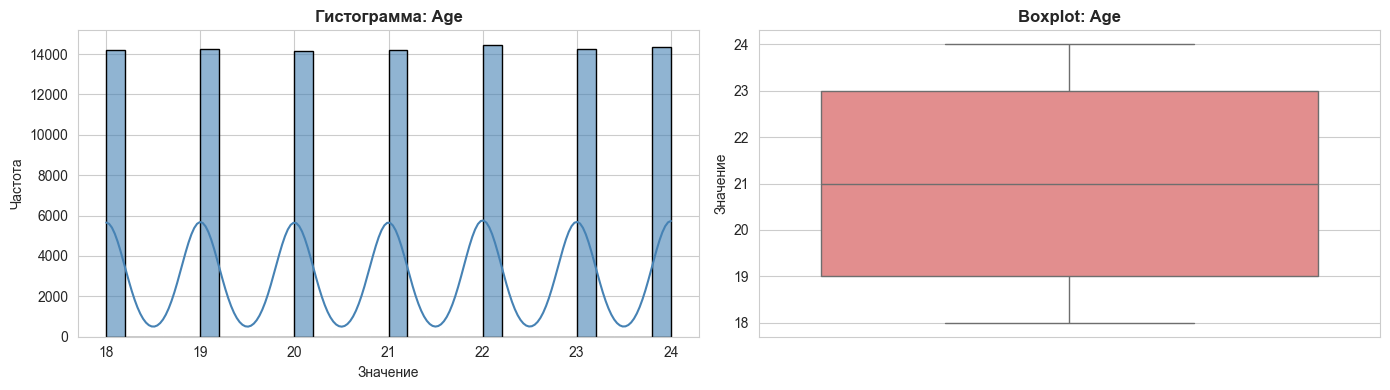

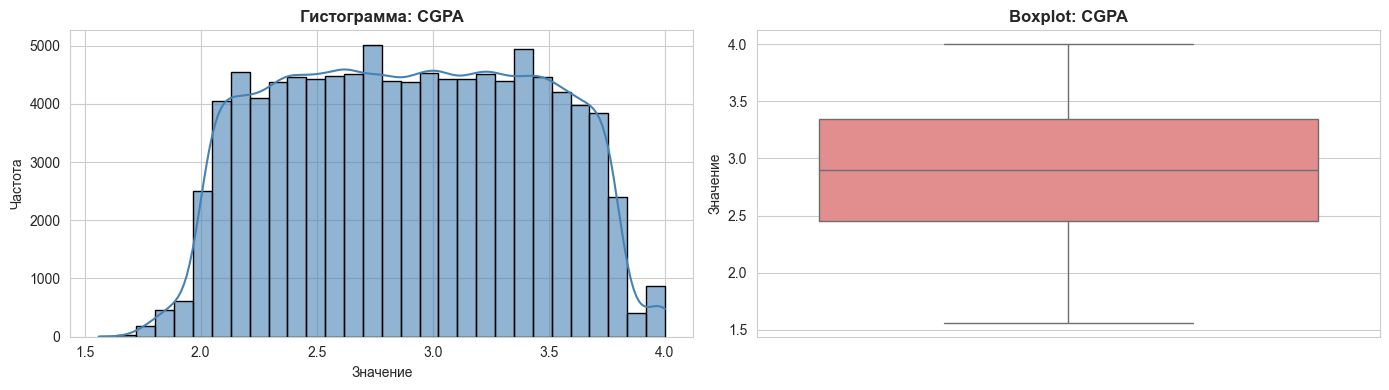

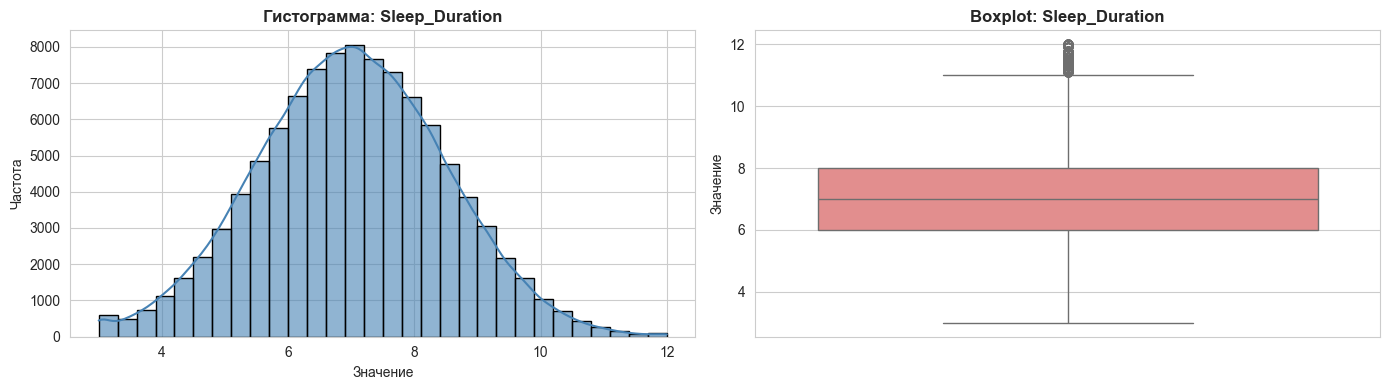

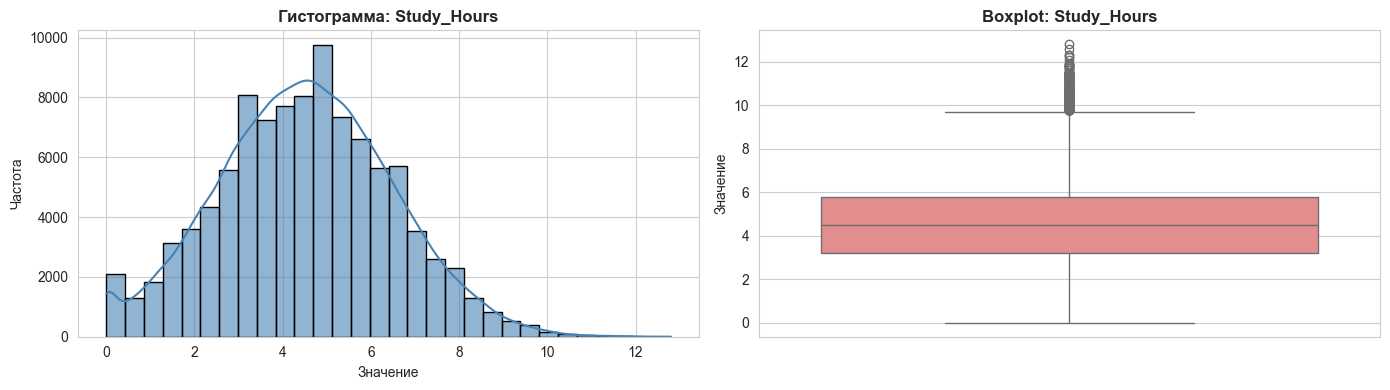

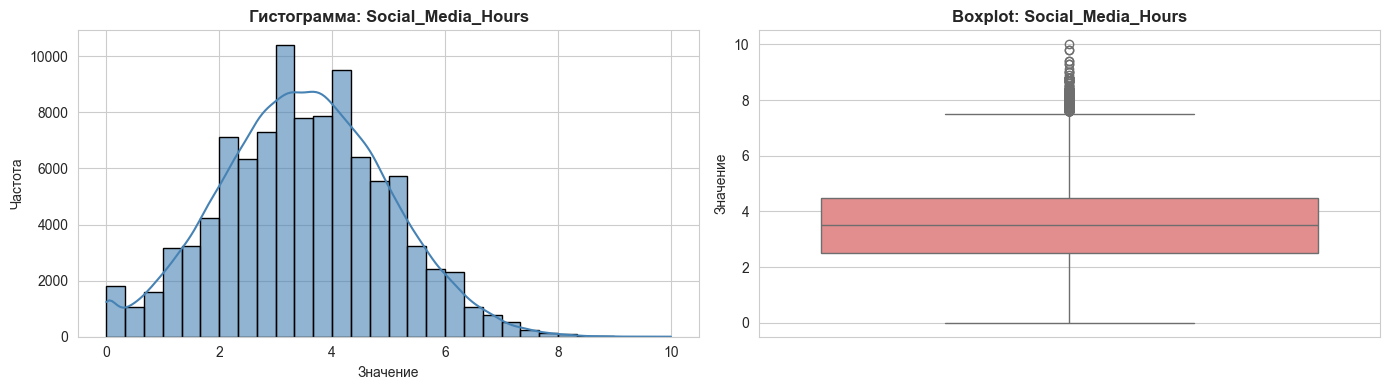

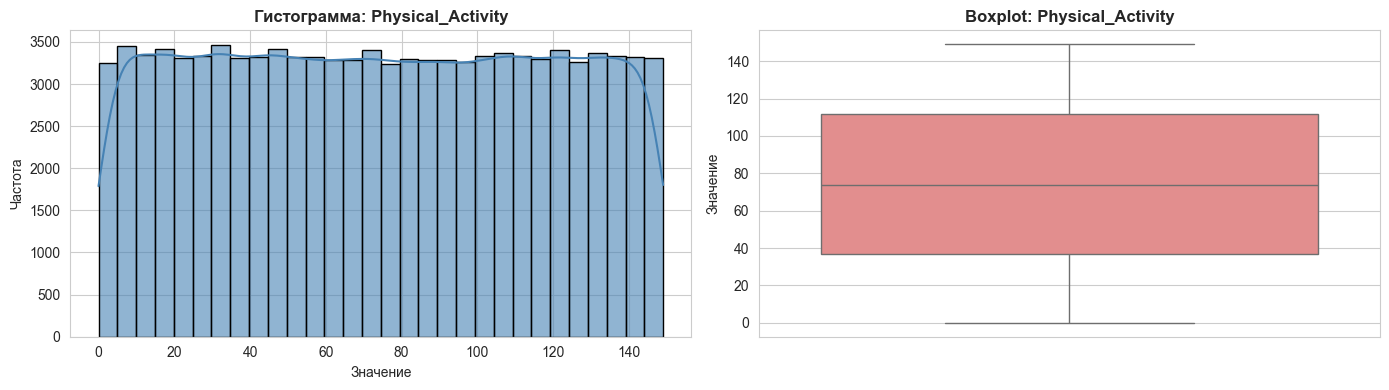

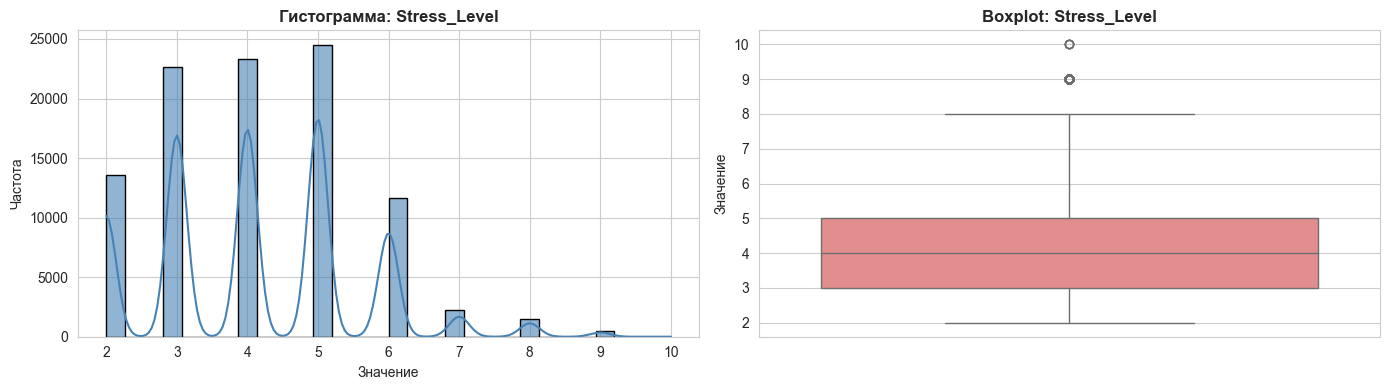

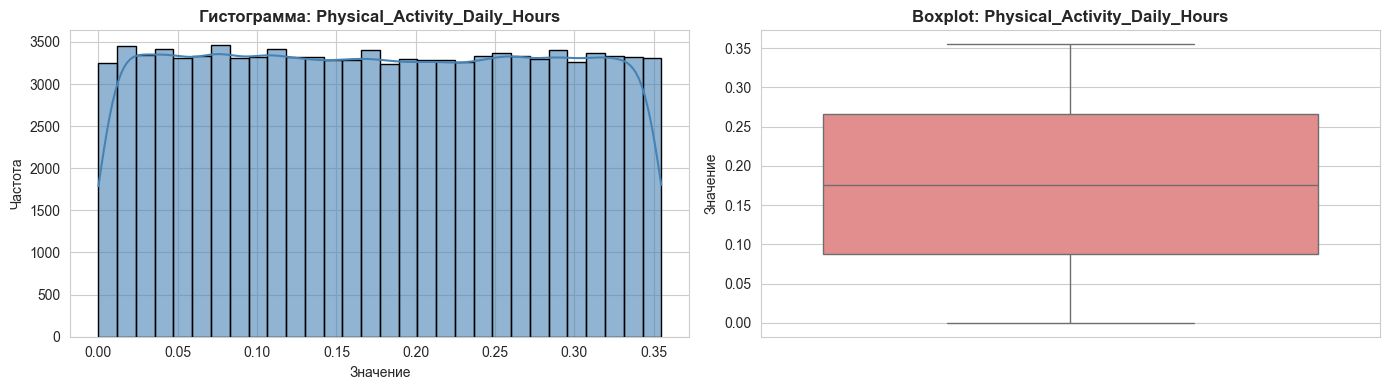

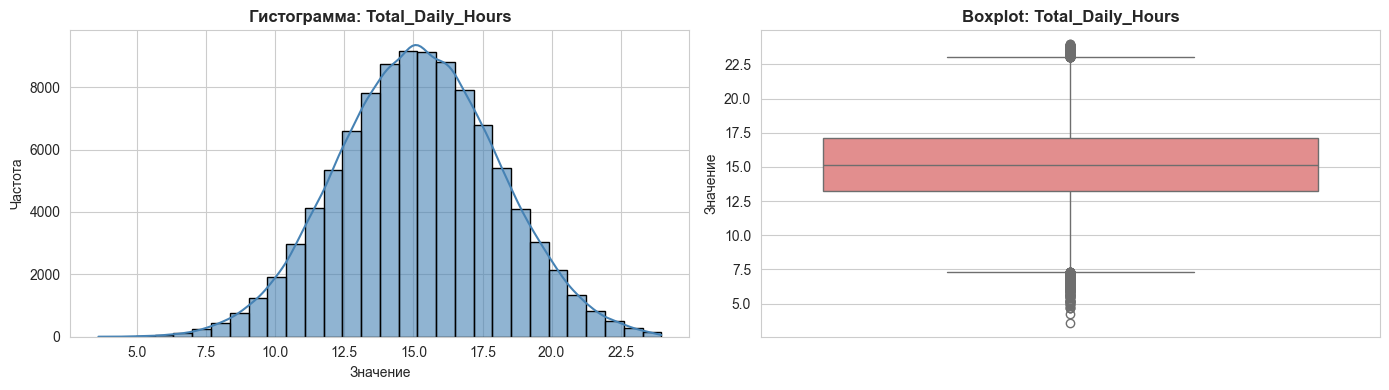

In [12]:
warnings.filterwarnings('ignore', category=UserWarning, module='matplotlib')

sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (16, 5)


num_features = df.select_dtypes(include='number').columns.tolist()

for feat in num_features:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Гистограмма + KDE
    sns.histplot(data=df, x=feat, bins=30, kde=True, ax=axes[0],
                 color='steelblue', edgecolor='black', alpha=0.6)
    axes[0].set_title(f'Гистограмма: {feat}', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Значение')
    axes[0].set_ylabel('Частота')

    # Boxplot
    sns.boxplot(data=df, y=feat, ax=axes[1], color='lightcoral')
    axes[1].set_title(f'Boxplot: {feat}', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Значение')

    plt.tight_layout()
    plt.show()

Что мы видим на графиках:
- Age: распределение равномерное в диапазоне 18-24 лет
- CGPA: наблюдается нормальное распределение
- Sleep Duration: большинство студентов спят около 7 часов
- Study Hours: распределение имеет небольшой скос влево
- Stress Level: заметно, что уровень стресса распределен дискретно
- Total_Daily_Hours: имеет скос вправо

#### Изучим отдельно выбросы

Проведем чистку с помощью квартилей

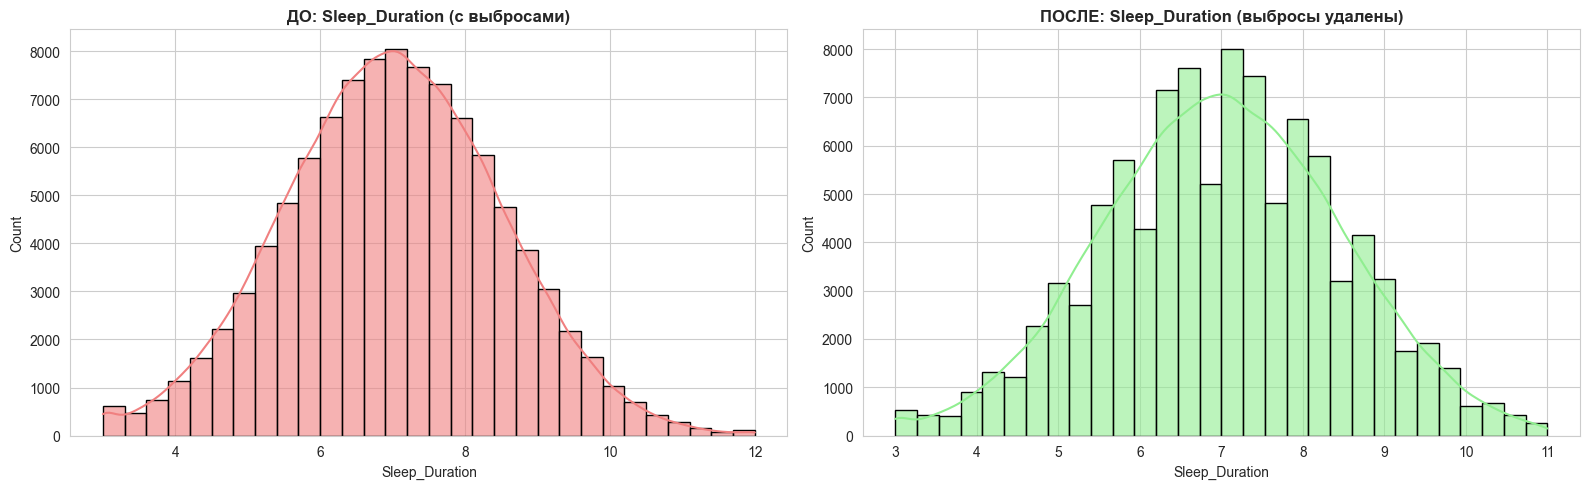

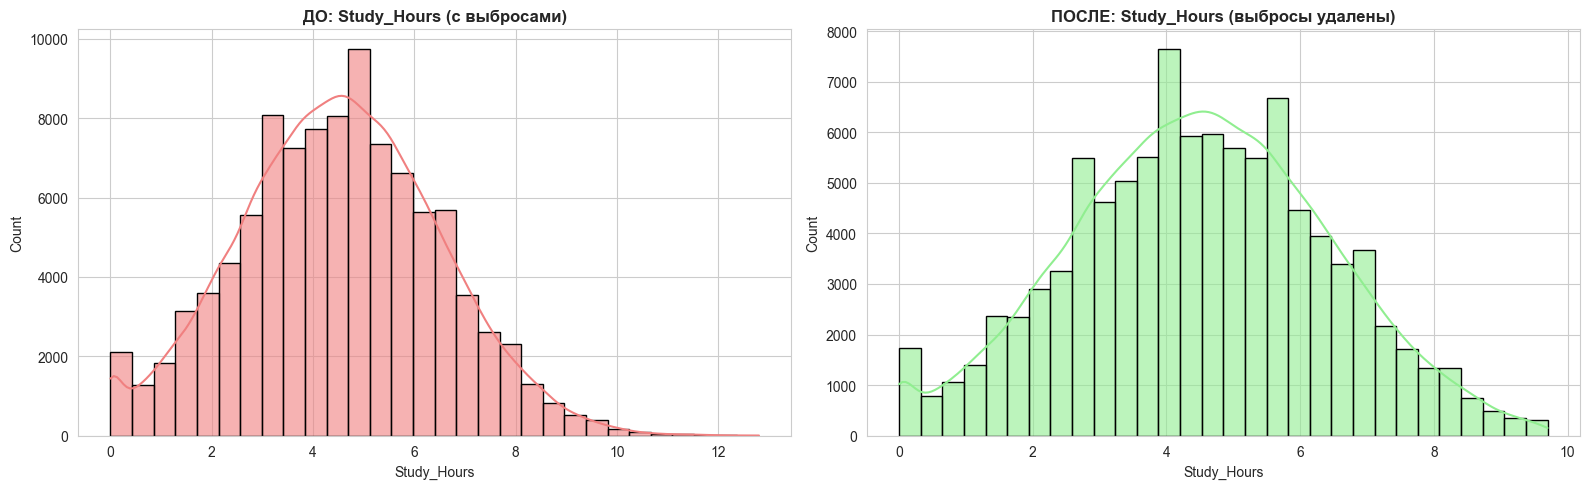

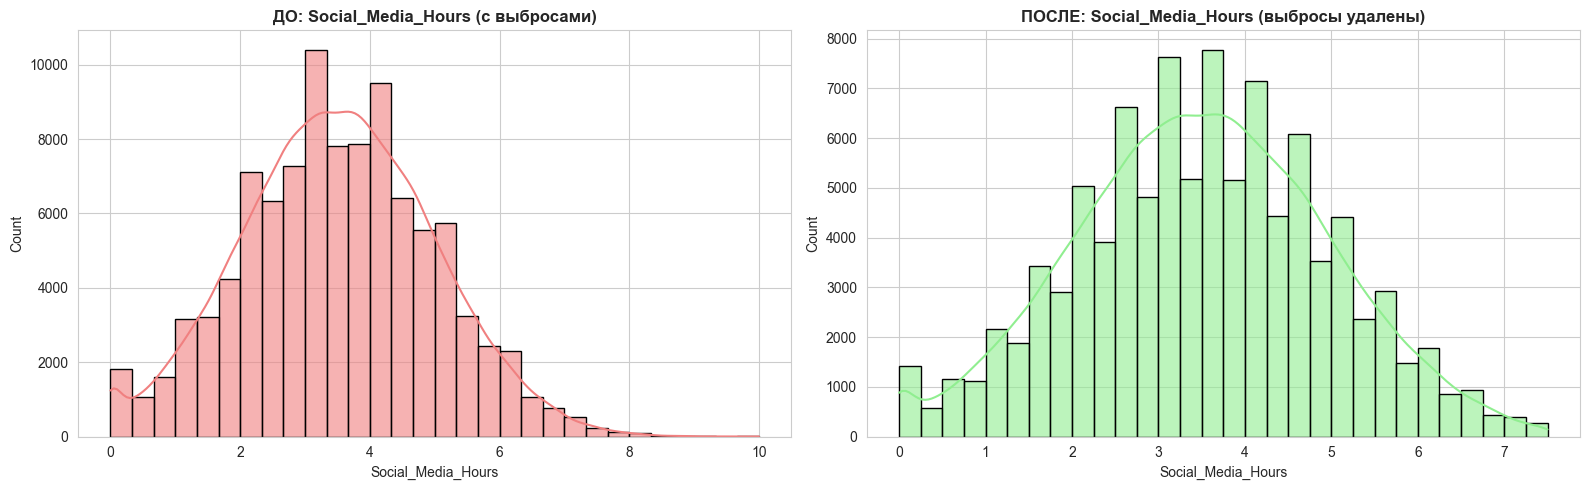

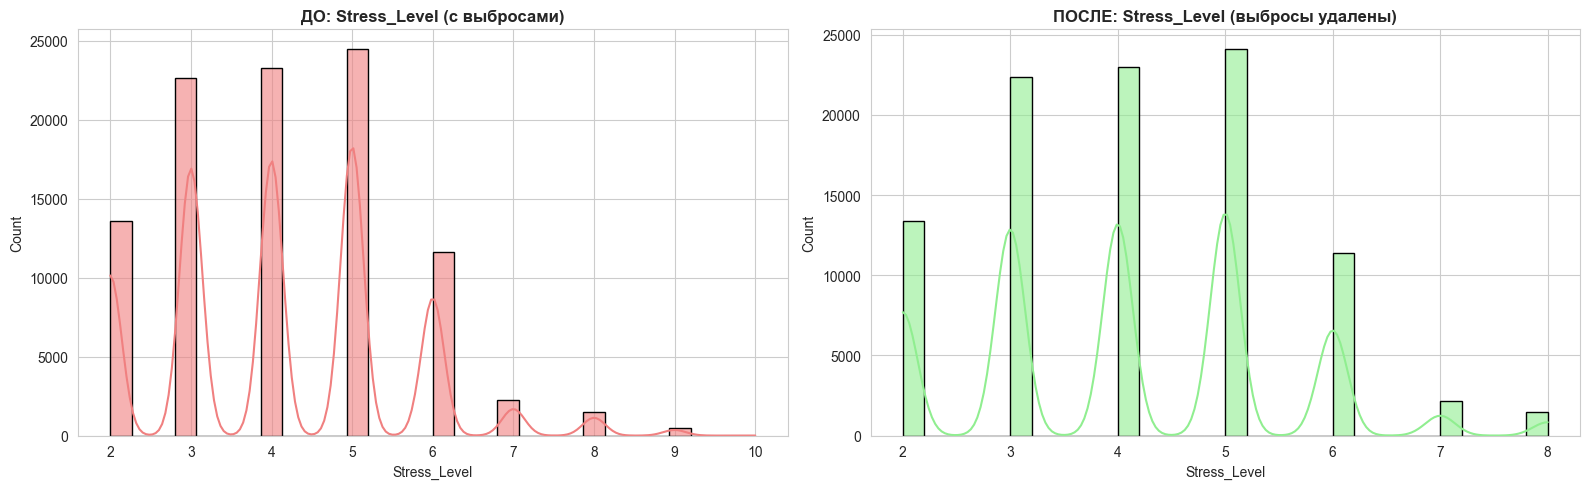

In [13]:
outliers_features = ['Sleep_Duration', 'Study_Hours', 'Social_Media_Hours', 'Stress_Level']

df_clean = df.copy()

for feat in num_features:
  Q1 = df_clean[feat].quantile(0.25)
  Q3 = df_clean[feat].quantile(0.75)
  IQR = Q3 - Q1

  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  df_clean = df_clean[(df_clean[feat] >= lower_bound) & (df_clean[feat] <= upper_bound)]

for feat in outliers_features:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # График ДО
    sns.histplot(data=df, x=feat, bins=30, kde=True, ax=axes[0], color='lightcoral', edgecolor='black', alpha=0.6)
    axes[0].set_title(f'ДО: {feat} (с выбросами)', fontsize=12, fontweight='bold')

    # График ПОСЛЕ
    sns.histplot(data=df_clean, x=feat, bins=30, kde=True, ax=axes[1], color='lightgreen', edgecolor='black', alpha=0.6)
    axes[1].set_title(f'ПОСЛЕ: {feat} (выбросы удалены)', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.show()

# Дальнейшие шаги (балансировка, обучение моделей) — на данных без выбросов по IQR
df = df_clean.reset_index(drop=True)


 После удаления выбросов кривые плотности (KDE) на зеленых графиках стали более симметричными
 Sleep Duration: исчезли значения менее 3 и более 11–12 часов
 Study Hours: исчезли студенты, которые учатся по 12+ часов в день
 Social Media Hours: ушли значения выше 7-8 часов
 Stress Level: ушли крайние значения

#### проведем анализ категориальных признаков

Числовые данные мы изучили, теперь посмотрим на распределение студентов по полу, факультетам и наличию депрессии. Это поможет понять, насколько сбалансирована наша выборка

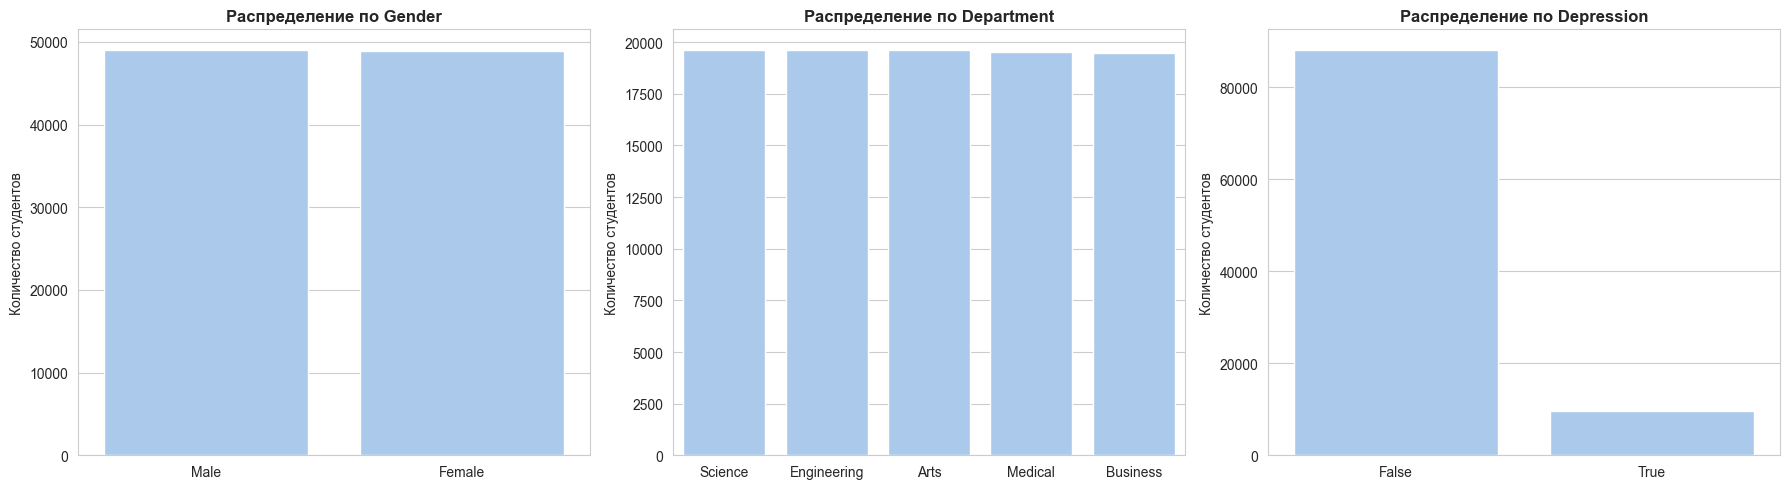

In [14]:
sns.set_palette("pastel")
plt.rcParams['figure.figsize'] = (18, 5)

# Список категориальных колонок (Gender, Department, Depression)
cat_features = ['Gender', 'Department', 'Depression']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(cat_features):
    sns.countplot(data=df, x=col, ax=axes[i], order=df[col].value_counts().index)
    axes[i].set_title(f'Распределение по {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Количество студентов')

plt.tight_layout()
plt.show()

мы видим, что практически все признаки сбалансированны, однако студентов с депрессией сильно меньше

#### Сбалансируем количество студентов с депрессией и без неё

In [15]:
# Разделяем на два класса
df_depressed = df[df['Depression'] == True]
df_healthy = df[df['Depression'] == False]

# Берем случайную подборку здоровых студентов, равную количеству депрессивных
df_healthy_downsampled = df_healthy.sample(n=len(df_depressed), random_state=42)

# Соединяем обратно
df_balanced = pd.concat([df_depressed, df_healthy_downsampled])

df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)


#### Перейдем к кодированию категориальных признаков

Используем Label Encoding для бинарных признаков (Gender и Depression) и One-Hot Encoding для Department

In [16]:
# Создаем копию для кодирования
df_encoded = df_balanced.copy()

df_encoded['Gender'] = df_encoded['Gender'].astype('category').cat.codes
df_encoded['Depression'] = df_encoded['Depression'].astype(int)

ohe = OneHotEncoder(variables=['Department'], drop_last=True)
df_encoded = ohe.fit_transform(df_encoded)

Построим матрицу корреляций

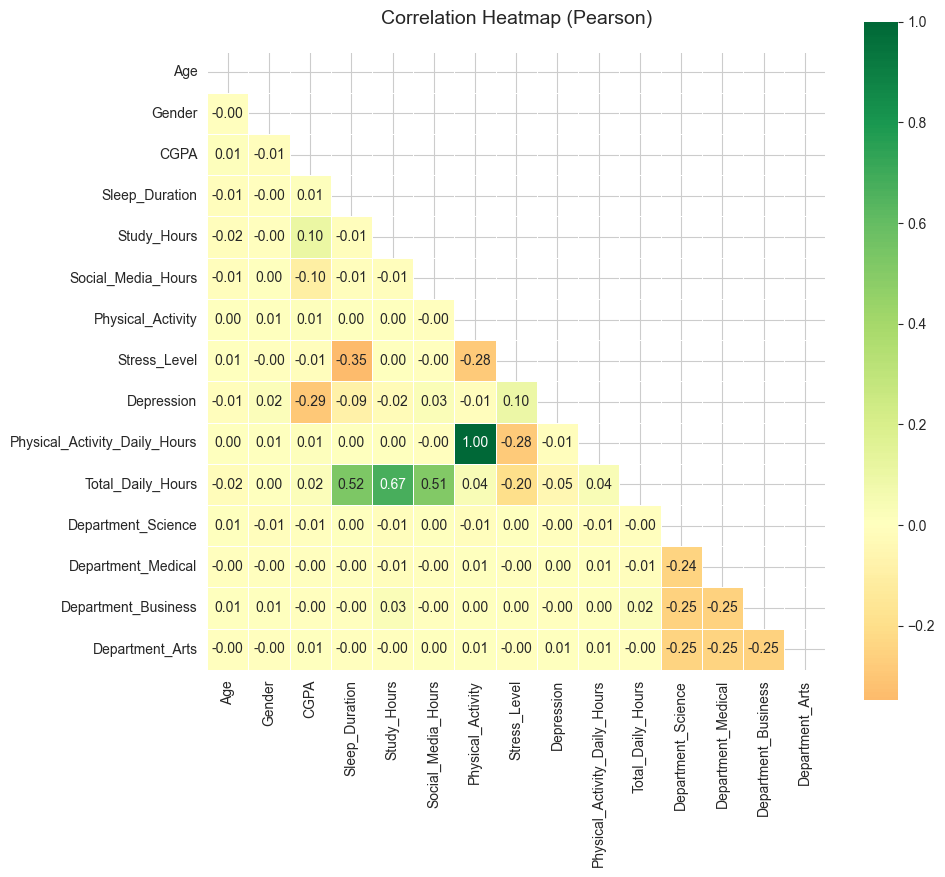

In [17]:
def plot_correlation_heatmap(dataframe, method='pearson'):
    numeric_df = dataframe.select_dtypes(include=[np.number])
    corr = numeric_df.corr(method=method)

    plt.figure(figsize=(10, 10))

    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn', center=0, square=True, linewidths=0.5, cbar_kws={"shrink": .8})

    plt.title(f'Correlation Heatmap ({method.capitalize()})', fontsize=14, pad=20)
    plt.tight_layout()
    plt.show()

plot_correlation_heatmap(df_encoded)

По матрице мы видим, что самая сильная связь у депрессии наблюдается с CGPA (-0.29). Отрицательная корреляция говорит о том, что у студентов с более высоким средним баллом риск депрессии в этом датасете ниже. Также есть связь между уровнем стресса и сном(-0.38), и физической активностью(-0.31). Также Стали видны лишние колонки, Physical_Activity и Total_Daily_Hours. Их надо удалить

In [18]:
cols_to_drop = ['Physical_Activity', 'Total_Daily_Hours']
df_final = df_encoded.drop(columns=cols_to_drop)

Ещё раз посмотрим на матрицу корреляций

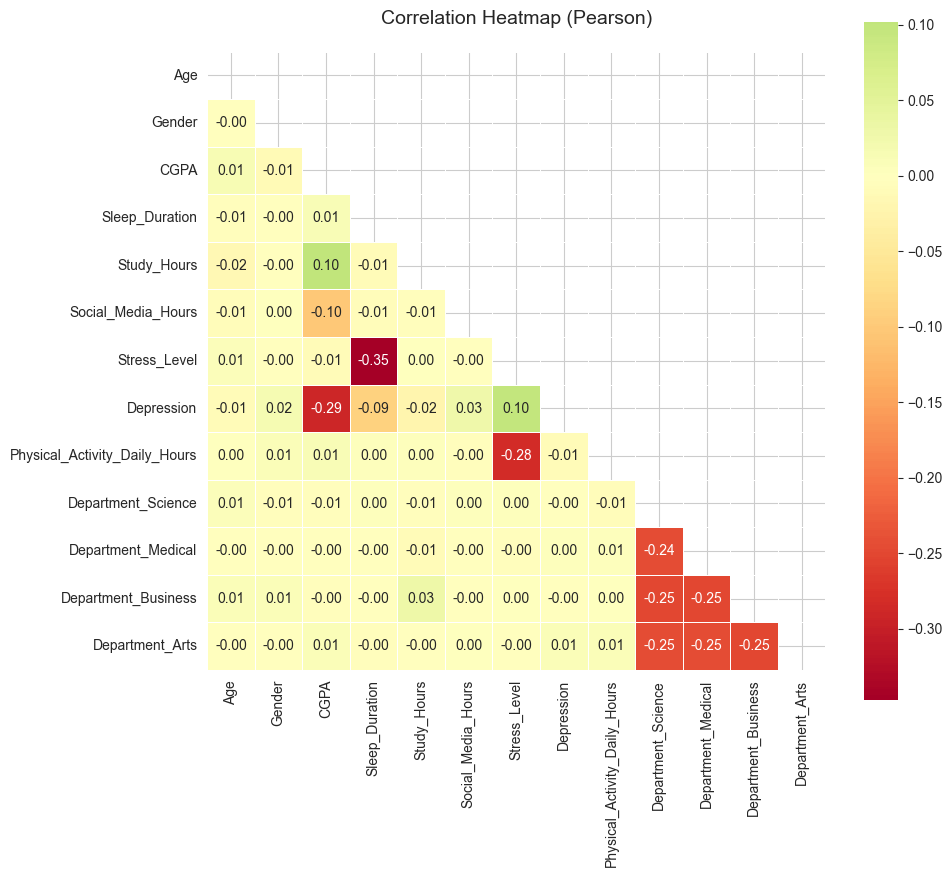

In [19]:
plot_correlation_heatmap(df_final)

Здесь уже почти нет созависимых признаков, можем переходить к следующему шагу

#### Feature Engineering


Спроектируем дополнительные признаки из уже имеющихся столбцов:

- **Stress_x_Sleep** и **Stress_x_Social** — произведения для моделирования взаимодействий (стресс усиливает/сочетается с укороченным сном и с временем в соцсетях).
- **Lifestyle_hours_sum** — сумма ключевых часов в сутках по датасету; **Unallocated_hours** — остаток до 24 ч (свободное/неразмеченное время).

#### Разделим данные на обучающую, валидационную и тестовую выборки


In [21]:
# Взаимодействие стресса и сна (по корреляционной матрице они связаны)
df_final['Stress_x_Sleep'] = df_final['Stress_Level'] * df_final['Sleep_Duration']
# Совместная нагрузка: стресс и время в соцсетях
df_final['Stress_x_Social'] = df_final['Stress_Level'] * df_final['Social_Media_Hours']
# Сколько часов в сутках уже «разложено» по режиму
df_final['Lifestyle_hours_sum'] = (
    df_final['Sleep_Duration']
    + df_final['Study_Hours']
    + df_final['Social_Media_Hours']
    + df_final['Physical_Activity_Daily_Hours']
)
# Остаток суток (не занятый сном, учёбой, соцсетями и физактивностью)
df_final['Unallocated_hours'] = (24.0 - df_final['Lifestyle_hours_sum']).clip(lower=0)

# отношение отдыха к учебе
df_final["Recovery"] = df_final["Sleep_Duration"] * df_final["Physical_Activity_Daily_Hours"] / (df_final['Study_Hours'] + 0.1)
# усталость
df_final["Hard_Job"] = df_final["Study_Hours"] * df_final["Physical_Activity_Daily_Hours"]
# Определяем признаки (X) и целевые переменные (y)
# Убираем оба таргета из признаков
X = df_final.drop(columns=['CGPA', 'Depression'], errors='ignore')
y_reg = df_final['CGPA']
y_cls = df_final['Depression']

# Сначала отделяем 60% на обучение и 40% на временный набор
X_train, X_temp, y_train_reg, y_temp_reg, y_train_cls, y_temp_cls = train_test_split(X, y_reg, y_cls, test_size=0.4, random_state=42)

# 3. Делим временный набор пополам (20% Val и 20% Test от общего объема)
X_val, X_test, y_val_reg, y_test_reg, y_val_cls, y_test_cls = train_test_split( X_temp, y_temp_reg, y_temp_cls, test_size=0.5, random_state=42)

print(f"Размер обучающей выборки: {X_train.shape[0]}")
print(f"Размер валидационной выборки: {X_val.shape[0]}")
print(f"Размер тестовой выборки: {X_test.shape[0]}")

df_final.info()

Размер обучающей выборки: 11630
Размер валидационной выборки: 3877
Размер тестовой выборки: 3877
<class 'pandas.DataFrame'>
RangeIndex: 19384 entries, 0 to 19383
Data columns (total 19 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            19384 non-null  int64  
 1   Gender                         19384 non-null  int8   
 2   CGPA                           19384 non-null  float64
 3   Sleep_Duration                 19384 non-null  float64
 4   Study_Hours                    19384 non-null  float64
 5   Social_Media_Hours             19384 non-null  float64
 6   Stress_Level                   19384 non-null  int64  
 7   Depression                     19384 non-null  int64  
 8   Physical_Activity_Daily_Hours  19384 non-null  float64
 9   Department_Science             19384 non-null  int64  
 10  Department_Medical             19384 non-null  int64  
 11  Department_Business 

опять посмотрим как коррелируют признаки

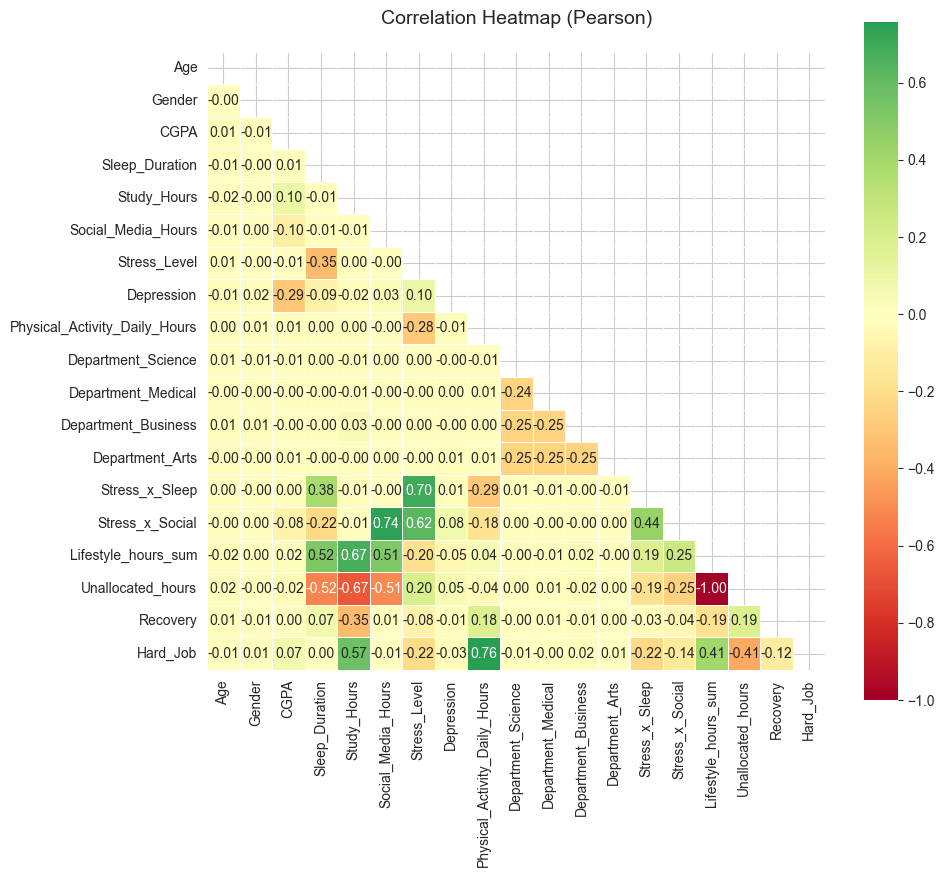

In [22]:
plot_correlation_heatmap(df_final)

видим что Unallocated_hours коррелирует с Lifestyle_hours_sum (что достаточно логично), удалимка её

In [23]:
cols_to_drop = ['Unallocated_hours']
df_final = df_final.drop(columns=cols_to_drop)

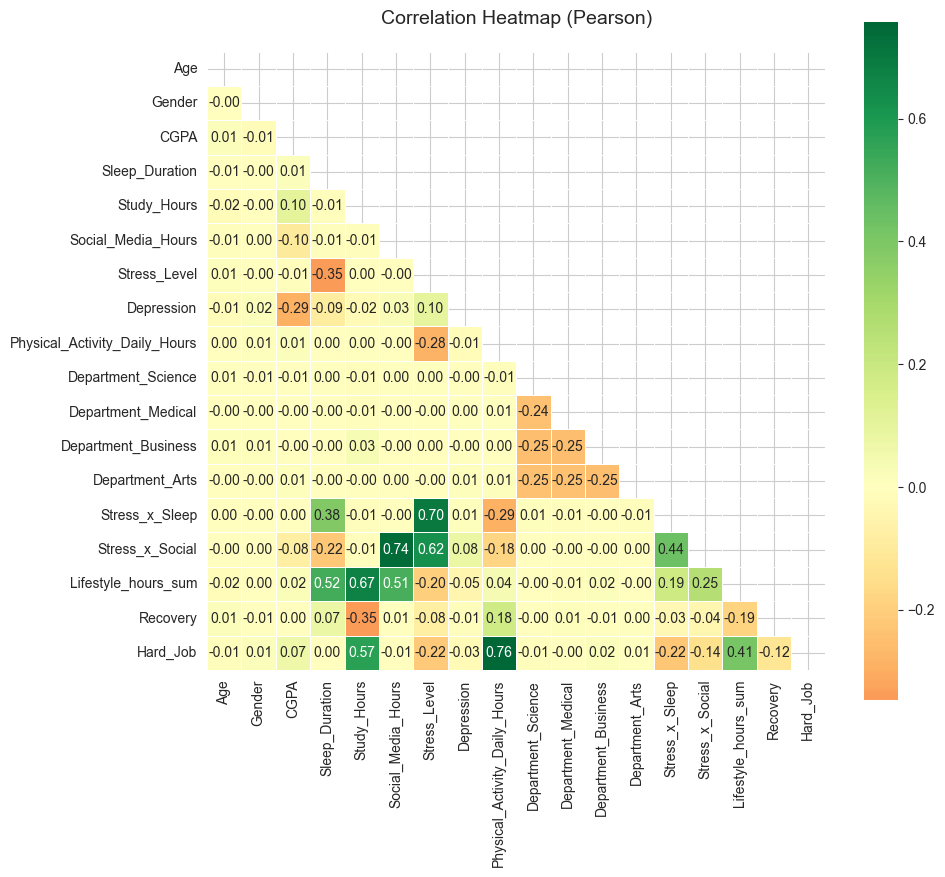

In [24]:
plot_correlation_heatmap(df_final)

Вот теперь идем дольше

In [25]:
scaler = StandardScaler()

# Обучаем scaler только на тренировочных данных
X_train_scaled = scaler.fit_transform(X_train)

# Применяем (трансформируем) к валидации и тесту
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Превратим обратно в DataFrame для удобства
X_train_final = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_val_final = pd.DataFrame(X_val_scaled, columns=X.columns, index=X_val.index)
X_test_final = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

print(f"Число признаков после FE и перед масштабированием: {X.shape[1]}")
X_train_final.head()

Число признаков после FE и перед масштабированием: 17


,Age,Gender,Sleep_Duration,Study_Hours,Social_Media_Hours,Stress_Level,Physical_Activity_Daily_Hours,Department_Science,Department_Medical,Department_Business,Department_Arts,Stress_x_Sleep,Stress_x_Social,Lifestyle_hours_sum,Unallocated_hours,Recovery,Hard_Job
2754,-1.477005,-0.995539,0.322958,-1.419423,-0.572291,0.530096,1.504374,-0.498522,-0.493138,-0.503893,2.016267,0.879453,-0.167580,-1.033454,1.033454,0.488927,-0.356280
12830,1.526329,-0.995539,0.653400,0.766480,0.656461,-0.144266,0.697621,-0.498522,-0.493138,1.984548,-0.495966,0.331844,0.369284,1.236335,-1.236335,-0.111459,1.130020
9299,0.024662,1.004481,1.116019,0.298072,-1.254931,-0.818627,-0.823685,2.005931,-0.493138,-0.503893,-0.495966,-0.256329,-1.169727,0.119548,-0.119548,-0.212126,-0.538669
11148,1.526329,-0.995539,1.314284,0.974662,0.383405,-0.818627,-1.630437,2.005931,-0.493138,-0.503893,-0.495966,-0.165060,-0.310744,1.505004,-1.505004,-0.294902,-1.212684
4077,1.025773,1.004481,-0.932722,-1.367378,-0.094443,-1.492989,1.527424,2.005931,-0.493138,-0.503893,-0.495966,-1.757183,-0.966912,-1.421719,1.421719,0.259306,-0.294433


Не пугаемся отрицательным значениям. Они появились из-за использования StandardScaler. Этот метод сдвигает и масштабирует данные так, что каждое начение заменяется на искодное значение минус среднее врифметическое этого признака и делит на стандартное отклонение

#### Переходим к Линейной регрессии

Предскажем успеваемость студентов, а так же выведем метрики модели


Метрики для Train:
  MAE:  0.4720
  RMSE: 0.5417
  R²:   0.0222
  MAPE: 17.55%

Метрики для Validation:
  MAE:  0.4808
  RMSE: 0.5477
  R²:   0.0213
  MAPE: 17.99%

Метрики для Test:
  MAE:  0.4743
  RMSE: 0.5419
  R²:   0.0269
  MAPE: 17.63%


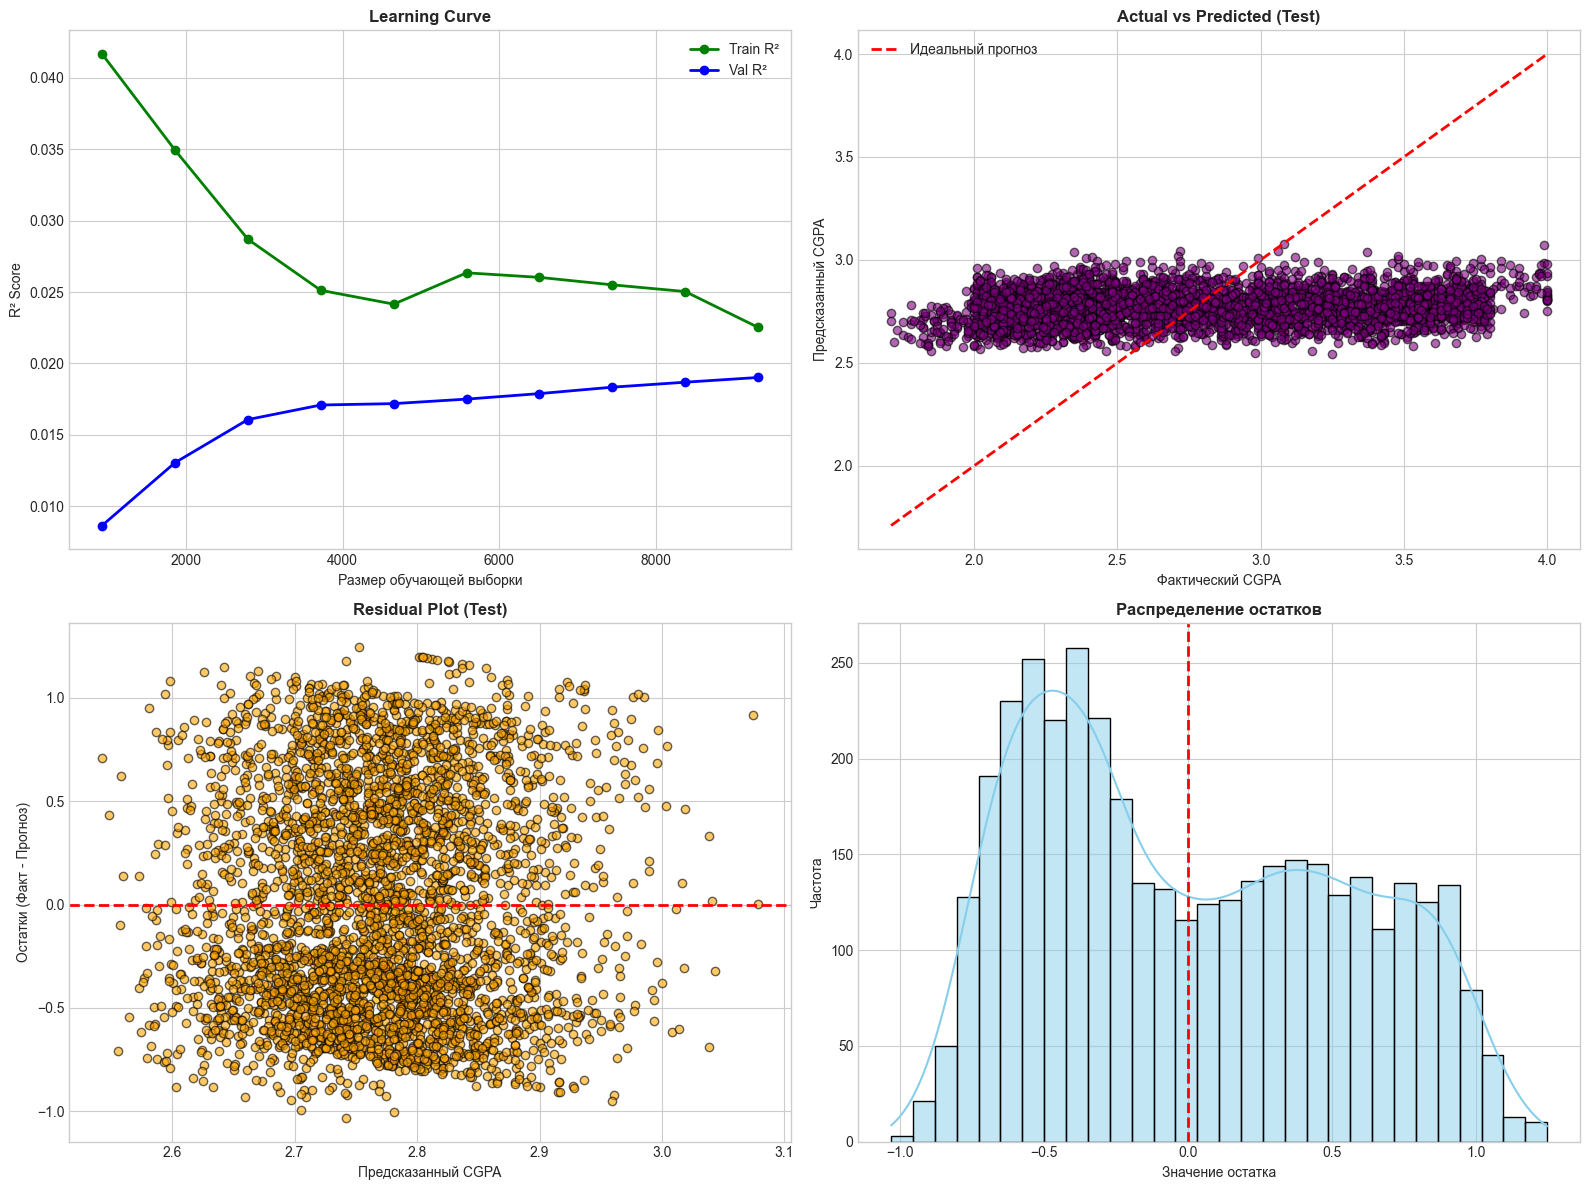


Влияние признаков на CGPA:
Study_Hours                      0.048924
Hard_Job                         0.033600
Stress_x_Sleep                   0.027807
Recovery                         0.026585
Stress_x_Social                  0.020178
Department_Arts                  0.007443
Unallocated_hours                0.006539
Age                              0.004367
Department_Business              0.000544
Department_Science               0.000465
Department_Medical              -0.004108
Lifestyle_hours_sum             -0.006539
Gender                          -0.009487
Sleep_Duration                  -0.010733
Physical_Activity_Daily_Hours   -0.019219
Stress_Level                    -0.038486
Social_Media_Hours              -0.064347
dtype: float64


In [26]:
#  Создаем и обучаем модель
model_reg = LinearRegression()
model_reg.fit(X_train_final, y_train_reg)

#  Получаем прогнозы
y_train_pred = model_reg.predict(X_train_final)
y_val_pred = model_reg.predict(X_val_final)
y_test_pred = model_reg.predict(X_test_final)

#Оцениваем качество модели
def evaluate_model(y_true, y_pred, dataset_name="Dataset"):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100

    print(f"\nМетрики для {dataset_name}:")
    print(f"  MAE:  {mae:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  R²:   {r2:.4f}")
    print(f"  MAPE: {mape:.2f}%")

    return {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}

#  Оцениваем на всех трех выборках
train_metrics = evaluate_model(y_train_reg, y_train_pred, "Train")
val_metrics = evaluate_model(y_val_reg, y_val_pred, "Validation")
test_metrics = evaluate_model(y_test_reg, y_test_pred, "Test")

#  Выводим результаты
plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(16, 12))

#  Кривая обучения
ax1 = plt.subplot(2, 2, 1)
train_sizes, train_scores, val_scores = learning_curve(
    model_reg, X_train_final, y_train_reg,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='r2',
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

ax1.plot(train_sizes, train_mean, 'o-', color='green', label='Train R²', linewidth=2)
ax1.plot(train_sizes, val_mean, 'o-', color='blue', label='Val R²', linewidth=2)
ax1.set_xlabel('Размер обучающей выборки')
ax1.set_ylabel('R² Score')
ax1.set_title('Learning Curve', fontsize=12, fontweight='bold')
ax1.legend()

# Фактическое и прогнозируемое
ax2 = plt.subplot(2, 2, 2)
ax2.scatter(y_test_reg, y_test_pred, alpha=0.6, edgecolors='black', color='purple')
ax2.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2, label='Идеальный прогноз')
ax2.set_xlabel('Фактический CGPA')
ax2.set_ylabel('Предсказанный CGPA')
ax2.set_title('Actual vs Predicted (Test)', fontsize=12, fontweight='bold')
ax2.legend()

#  Остатки
ax3 = plt.subplot(2, 2, 3)
residuals = y_test_reg - y_test_pred
ax3.scatter(y_test_pred, residuals, alpha=0.6, edgecolors='black', color='orange')
ax3.axhline(y=0, color='red', linestyle='--', lw=2)
ax3.set_xlabel('Предсказанный CGPA')
ax3.set_ylabel('Остатки (Факт - Прогноз)')
ax3.set_title('Residual Plot (Test)', fontsize=12, fontweight='bold')

#  Распределение остатков

ax4 = plt.subplot(2, 2, 4)
sns.histplot(residuals, bins=30, kde=True, ax=ax4, color='skyblue', edgecolor='black')
ax4.axvline(x=0, color='red', linestyle='--', lw=2)
ax4.set_xlabel('Значение остатка')
ax4.set_ylabel('Частота')
ax4.set_title('Распределение остатков', fontsize=12, fontweight='bold')


plt.tight_layout()
plt.show()
# Посмотрим на коэффициенты
weights = pd.Series(model_reg.coef_, index=X_train_final.columns).sort_values(ascending=False)
print("\nВлияние признаков на CGPA:")
print(weights)

Как мы видим, модель предсказывает очень плохо. Однако, на графике кривой обучения линии тренировочного (зеленая) и валидационного (синяя) сошлись. Значит переобучения нет).
Модель одинаково плохо работает как на данных на которых училась так и на других
Влияние признаков слишком маленькое

#### Переходим к задаче классификации

Напишем свою логическую регрессию

In [27]:
class LogisticRegressionCustom:
    def __init__(self, learning_rate=0.01, n_iterations=100, random_state=42, penalty='l2', alpha=0.01):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.random_state = random_state
        self.penalty = penalty
        self.alpha = alpha
        self.weights = None
        self.bias = None
        self.loss_history = []

    def _initialize_parameters(self, n_features):
        """Инициализация весов и смещения"""
        np.random.seed(self.random_state)
        self.weights = np.random.randn(n_features) * 0.01
        self.bias = 0.0

    def _sigmoid(self, z):
        """Сигмоидная функция активации"""
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    def _compute_loss(self, y_true, y_pred_proba):
        """Вычисление Binary Cross-Entropy Loss"""
        epsilon = 1e-15
        y_pred_proba = np.clip(y_pred_proba, epsilon, 1 - epsilon)
        loss = -np.mean(y_true * np.log(y_pred_proba) + (1 - y_true) * np.log(1 - y_pred_proba))

        if self.penalty == 'l2':
            loss += (self.alpha / (2 * len(y_true))) * np.sum(self.weights ** 2)
        return loss

    def fit(self, X, y):
        """Обучение модели градиентным спуском"""
        n_samples, n_features = X.shape
        self._initialize_parameters(n_features)
        self.loss_history = []

        for epoch in range(self.n_iterations):
            linear_output = np.dot(X, self.weights) + self.bias
            y_pred_proba = self._sigmoid(linear_output)

            loss = self._compute_loss(y, y_pred_proba)
            self.loss_history.append(loss)

            error = y_pred_proba - y
            dw = (1 / n_samples) * np.dot(X.T, error)
            db = (1 / n_samples) * np.sum(error)

            if self.penalty == 'l2':
                dw += (self.alpha / n_samples) * self.weights

            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db
        return self

    def predict_proba(self, X):
        """Вероятность принадлежности к классу 1"""
        linear_output = np.dot(X, self.weights) + self.bias
        return self._sigmoid(linear_output)

    def predict(self, X, threshold=0.5):
        """Предсказание класса (0 или 1)"""
        proba = self.predict_proba(X)
        return (proba >= threshold).astype(int)

#### Настроим параметры и перейдем к обучению

In [28]:
# Подбор learning rate и числа эпох по валидации (тест не используем, чтобы избежать подгонки)
lr_grid = [0.01, 0.05, 0.1, 0.3, 0.5]
epoch_grid = [400, 700, 1000]
rows = []
for lr in lr_grid:
    for n_ep in epoch_grid:
        m = LogisticRegressionCustom(
            learning_rate=lr,
            n_iterations=n_ep,
            random_state=42,
            penalty='l2',
            alpha=0.1,
        )
        m.fit(X_train_final, y_train_cls)
        val_proba = m.predict_proba(X_val_final)
        val_pred = m.predict(X_val_final)
        auc = roc_auc_score(y_val_cls, val_proba)
        f1 = f1_score(y_val_cls, val_pred, zero_division=0)
        rows.append((lr, n_ep, auc, f1))

exp_df = pd.DataFrame(rows, columns=['lr', 'epochs', 'val_AUC_ROC', 'val_F1'])
print(exp_df.sort_values('val_AUC_ROC', ascending=False).head(8).to_string(index=False))

best_idx = exp_df['val_AUC_ROC'].idxmax()
learning_rate = float(exp_df.loc[best_idx, 'lr'])
n_epochs = int(exp_df.loc[best_idx, 'epochs'])
print(f"\nВыбрано по валидации: learning_rate={learning_rate}, epochs={n_epochs}\n")

model_cls = LogisticRegressionCustom(
    learning_rate=learning_rate,
    n_iterations=n_epochs,
    random_state=42,
    penalty='l2',
    alpha=0.1,
)
model_cls.fit(X_train_final, y_train_cls)

y_train_pred = model_cls.predict(X_train_final)
y_val_pred = model_cls.predict(X_val_final)
y_test_pred = model_cls.predict(X_test_final)
y_test_proba = model_cls.predict_proba(X_test_final)



 lr  epochs  val_AUC_ROC   val_F1
0.3    1000     0.556853 0.477419
0.3     700     0.556738 0.475242
0.5     400     0.556701 0.476135
0.5     700     0.556682 0.477559
0.5    1000     0.556601 0.478337
0.3     400     0.556479 0.479094
0.1    1000     0.556367 0.485303
0.1     700     0.556202 0.494312

Выбрано по валидации: learning_rate=0.3, epochs=1000



#### Оценим качество модели, выведем метрики

In [29]:
def evaluate_classification(y_true, y_pred, y_proba=None, dataset_name="Набор данных"):
    """Расчет и вывод метрик классификации"""
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc_roc = roc_auc_score(y_true, y_proba) if y_proba is not None else None

    print(f"\nМетрики для {dataset_name}:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    if auc_roc is not None:
        print(f"  AUC-ROC:   {auc_roc:.4f}")

    return {'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1': f1, 'AUC-ROC': auc_roc}

y_val_proba = model_cls.predict_proba(X_val_final)

train_metrics = evaluate_classification(y_train_cls, y_train_pred, dataset_name="Train")
val_metrics = evaluate_classification(y_val_cls, y_val_pred, y_proba=y_val_proba, dataset_name="Validation")
test_metrics = evaluate_classification(y_test_cls, y_test_pred, y_proba=y_test_proba, dataset_name="Test")


Метрики для Train:
  Accuracy:  0.5440
  Precision: 0.5565
  Recall:    0.4318
  F1-Score:  0.4863

Метрики для Validation:
  Accuracy:  0.5404
  Precision: 0.5534
  Recall:    0.4198
  F1-Score:  0.4774
  AUC-ROC:   0.5569

Метрики для Test:
  Accuracy:  0.5257
  Precision: 0.5350
  Recall:    0.3979
  F1-Score:  0.4564
  AUC-ROC:   0.5445


#### Визуализация

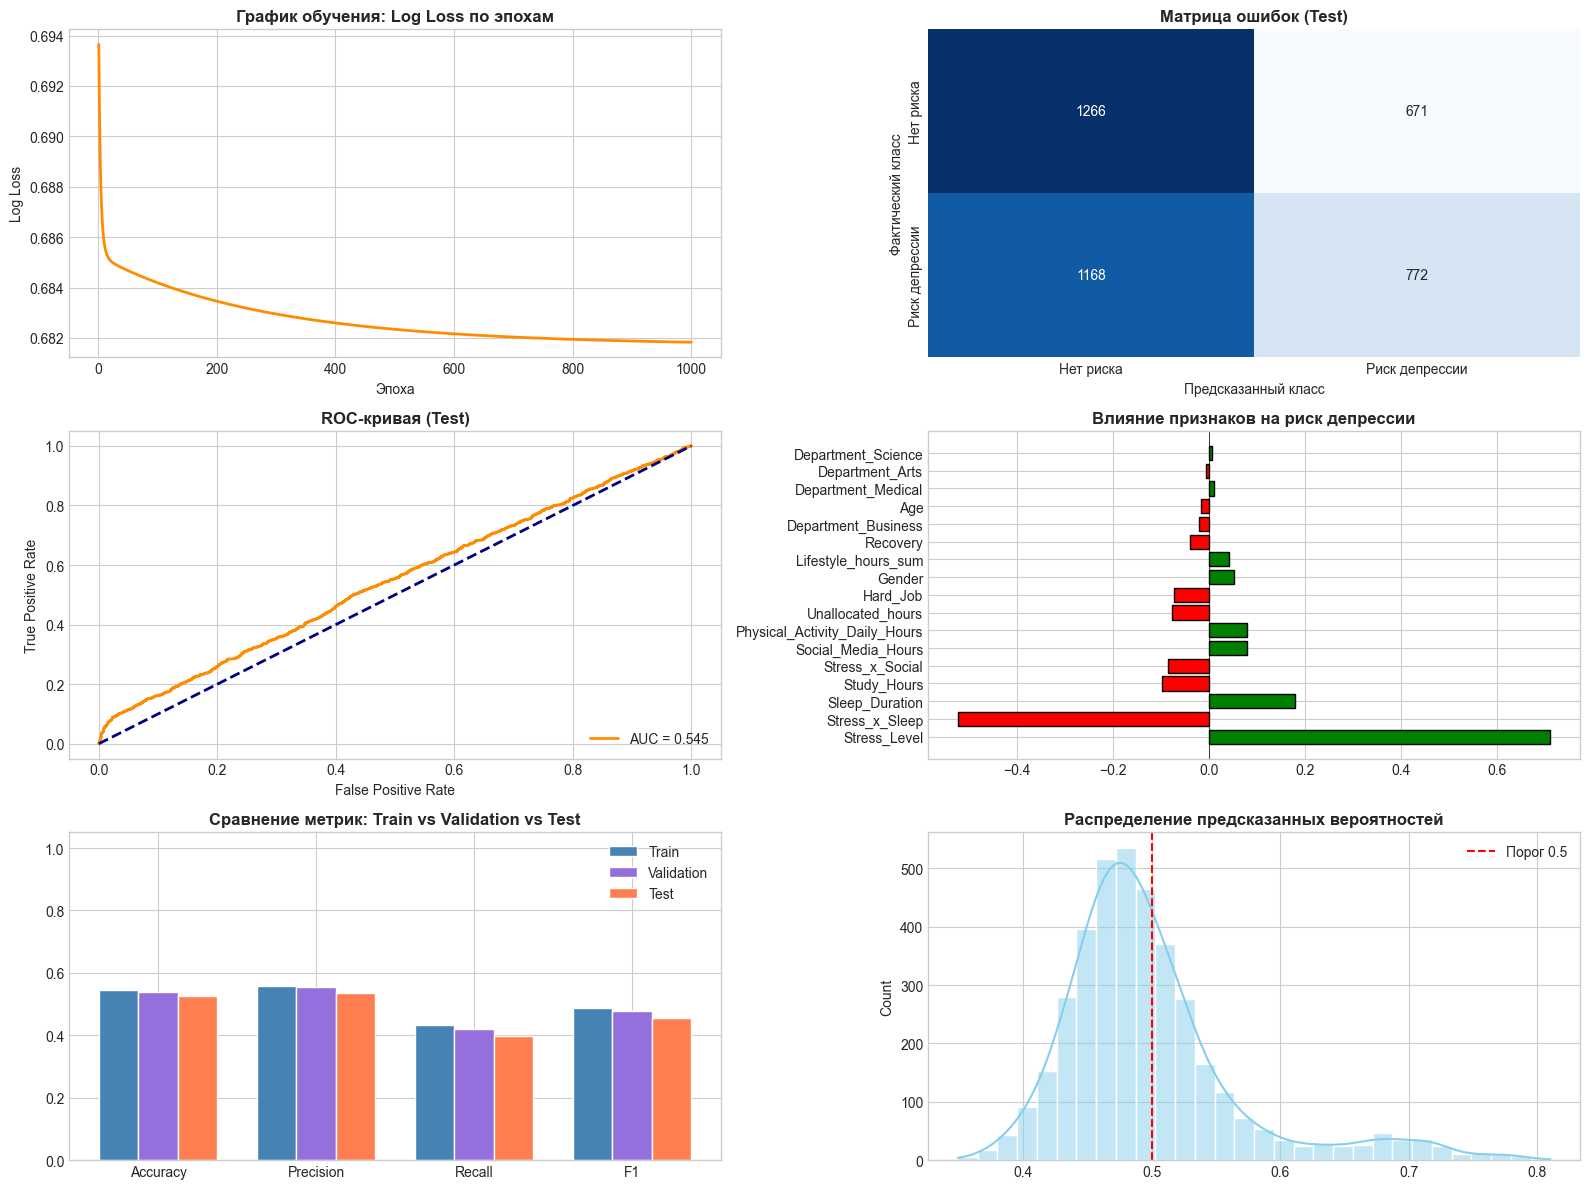

In [30]:
plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(16, 12))

# 4.1 История потерь
ax1 = plt.subplot(3, 2, 1)
ax1.plot(range(1, n_epochs + 1), model_cls.loss_history, color='darkorange', linewidth=2)
ax1.set_xlabel('Эпоха')
ax1.set_ylabel('Log Loss')
ax1.set_title('График обучения: Log Loss по эпохам', fontweight='bold')

# 4.2 Матрица ошибок (Test)
ax2 = plt.subplot(3, 2, 2)
cm = confusion_matrix(y_test_cls, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2, cbar=False)
ax2.set_xlabel('Предсказанный класс')
ax2.set_ylabel('Фактический класс')
ax2.set_title('Матрица ошибок (Test)', fontweight='bold')
ax2.set_xticklabels(['Нет риска', 'Риск депрессии'])
ax2.set_yticklabels(['Нет риска', 'Риск депрессии'])

# 4.3 ROC-кривая
ax3 = plt.subplot(3, 2, 3)
fpr, tpr, _ = roc_curve(y_test_cls, y_test_proba)
ax3.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {test_metrics["AUC-ROC"]:.3f}')
ax3.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax3.set_xlabel('False Positive Rate')
ax3.set_ylabel('True Positive Rate')
ax3.set_title('ROC-кривая (Test)', fontweight='bold')
ax3.legend(loc="lower right")

# 4.4 Важность признаков
ax4 = plt.subplot(3, 2, 4)
weights_df = pd.DataFrame({
    'feature': X_train_final.columns,
    'weight': model_cls.weights
}).sort_values(by='weight', key=lambda x: np.abs(x), ascending=False)

colors = ['green' if w > 0 else 'red' for w in weights_df['weight']]
ax4.barh(weights_df['feature'], weights_df['weight'], color=colors, edgecolor='black')
ax4.set_title('Влияние признаков на риск депрессии', fontweight='bold')
ax4.axvline(x=0, color='black', lw=0.5)

# 4.5 Сравнение метрик (Train / Validation / Test — нет большого разрыва ⇒ переобучение маловероятно)
ax5 = plt.subplot(3, 2, 5)
m_names = ['Accuracy', 'Precision', 'Recall', 'F1']
train_v = [train_metrics['Accuracy'], train_metrics['Precision'], train_metrics['Recall'], train_metrics['F1']]
val_v = [val_metrics['Accuracy'], val_metrics['Precision'], val_metrics['Recall'], val_metrics['F1']]
test_v = [test_metrics['Accuracy'], test_metrics['Precision'], test_metrics['Recall'], test_metrics['F1']]

x = np.arange(len(m_names))
w = 0.25
ax5.bar(x - w, train_v, w, label='Train', color='steelblue')
ax5.bar(x, val_v, w, label='Validation', color='mediumpurple')
ax5.bar(x + w, test_v, w, label='Test', color='coral')
ax5.set_xticks(x)
ax5.set_xticklabels(m_names)
ax5.set_ylim(0, 1.05)
ax5.set_title('Сравнение метрик: Train vs Validation vs Test', fontweight='bold')
ax5.legend()

# 4.6 Распределение вероятностей
ax6 = plt.subplot(3, 2, 6)
sns.histplot(y_test_proba, bins=30, kde=True, ax=ax6, color='skyblue')
ax6.axvline(x=0.5, color='red', linestyle='--', label='Порог 0.5')
ax6.set_title('Распределение предсказанных вероятностей', fontweight='bold')
ax6.legend()

plt.tight_layout()
plt.show()

Визуализация: lr=0.3, эпох=1000


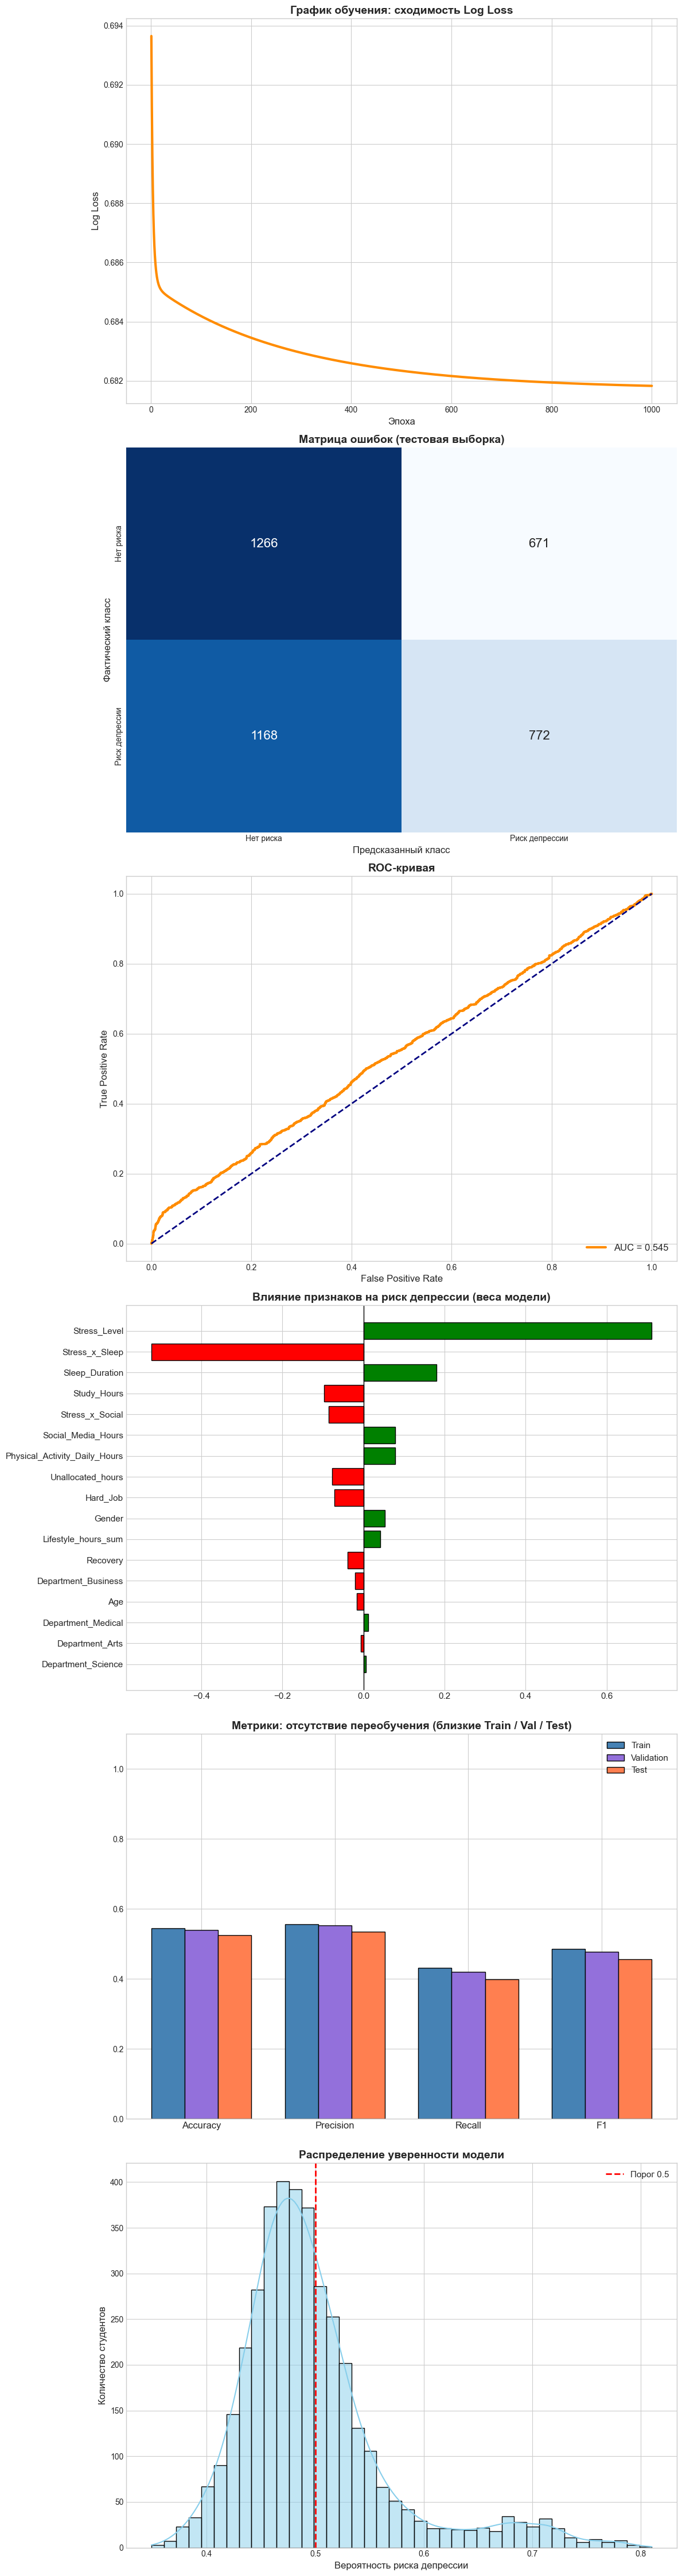

In [32]:
# Крупная визуализация для уже обученной model_cls (те же веса, что после подбора по валидации)
print(f"Визуализация: lr={learning_rate}, эпох={n_epochs}")

plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(6, 1, figsize=(12, 45))

axes[0].plot(range(1, n_epochs + 1), model_cls.loss_history, color='darkorange', linewidth=3)
axes[0].set_xlabel('Эпоха', fontsize=12)
axes[0].set_ylabel('Log Loss', fontsize=12)
axes[0].set_title('График обучения: сходимость Log Loss', fontsize=14, fontweight='bold')

cm = confusion_matrix(y_test_cls, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1], cbar=False, annot_kws={"size": 16})
axes[1].set_xlabel('Предсказанный класс', fontsize=12)
axes[1].set_ylabel('Фактический класс', fontsize=12)
axes[1].set_title('Матрица ошибок (тестовая выборка)', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(['Нет риска', 'Риск депрессии'])
axes[1].set_yticklabels(['Нет риска', 'Риск депрессии'])

fpr, tpr, _ = roc_curve(y_test_cls, y_test_proba)
axes[2].plot(fpr, tpr, color='darkorange', lw=3, label=f"AUC = {test_metrics['AUC-ROC']:.3f}")
axes[2].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[2].set_xlabel('False Positive Rate', fontsize=12)
axes[2].set_ylabel('True Positive Rate', fontsize=12)
axes[2].set_title('ROC-кривая', fontsize=14, fontweight='bold')
axes[2].legend(loc="lower right", fontsize=12)

weights_df = pd.DataFrame({
    'feature': X_train_final.columns,
    'weight': model_cls.weights
}).sort_values(by='weight', key=lambda x: np.abs(x), ascending=True)
colors = ['green' if w > 0 else 'red' for w in weights_df['weight']]
axes[3].barh(weights_df['feature'], weights_df['weight'], color=colors, edgecolor='black')
axes[3].set_title('Влияние признаков на риск депрессии (веса модели)', fontsize=14, fontweight='bold')
axes[3].axvline(x=0, color='black', lw=1)
axes[3].tick_params(axis='both', which='major', labelsize=11)

m_names = ['Accuracy', 'Precision', 'Recall', 'F1']
train_v = [train_metrics['Accuracy'], train_metrics['Precision'], train_metrics['Recall'], train_metrics['F1']]
val_v = [val_metrics['Accuracy'], val_metrics['Precision'], val_metrics['Recall'], val_metrics['F1']]
test_v = [test_metrics['Accuracy'], test_metrics['Precision'], test_metrics['Recall'], test_metrics['F1']]
x_axis = np.arange(len(m_names))
w = 0.25
axes[4].bar(x_axis - w, train_v, w, label='Train', color='steelblue', edgecolor='black')
axes[4].bar(x_axis, val_v, w, label='Validation', color='mediumpurple', edgecolor='black')
axes[4].bar(x_axis + w, test_v, w, label='Test', color='coral', edgecolor='black')
axes[4].set_xticks(x_axis)
axes[4].set_xticklabels(m_names, fontsize=12)
axes[4].set_ylim(0, 1.1)
axes[4].set_title('Метрики: отсутствие переобучения (близкие Train / Val / Test)', fontsize=14, fontweight='bold')
axes[4].legend(fontsize=11)

sns.histplot(y_test_proba, bins=40, kde=True, ax=axes[5], color='skyblue', edgecolor='black')
axes[5].axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Порог 0.5')
axes[5].set_xlabel('Вероятность риска депрессии', fontsize=12)
axes[5].set_ylabel('Количество студентов', fontsize=12)
axes[5].set_title('Распределение уверенности модели', fontsize=14, fontweight='bold')
axes[5].legend(fontsize=11)

plt.tight_layout()
plt.show()



После перебора гиперпараметров качество остаётся умеренным: линейная логистическая модель слабо улавливает сигнал в этом датасете.



#### Итого, можно сделать такие выводы.

- Итоговая точность на тесте обычно лишь немногу выше 50%: при сбалансированных классах это чуть лучше случайного угадывания.
- ROC-кривая близка к диагонали: много ошибок обоих типов.
- Перебор шага обучения и числа эпох по сетке с выбором лучшей пары по **AUC-ROC на валидации** формально выполняет требование экспериментов; существенного роста на тесте это не гарантирует (данные почти неразделимы линейно).
- При этом видны интерпретируемые направления эффектов (например, стресс и сон в сочетании с инженерными признаками).
- Метрики **Train / Validation / Test** близки — признаков выраженного переобучения нет.


#### Общий вывод

Линейная регрессия для CGPA, как правило, даёт низкий R²: связь успеваемости с режимом в этом наборе слабо описывается линейной моделью.
Логистическая регрессия (градиентный спуск с подбором шага и эпох по валидации) также показывает скромный AUC-ROC; при этом знаки весов согласуются с ожиданиями (стресс и режим сна/нагрузки).
Сравнение метрик на обучающей, валидационной и тестовой выборках без большого разрыва подтверждает отсутствие сильного переобучения при корректном масштабировании и разделении данных.
